# Topic Classification Using EmpatheticDialogues

## Objective

The objective of this notebook is to build a single-label topic classification
model for the EmoExpress application using the EmpatheticDialogues dataset.

EmpatheticDialogues contains conversations grounded in emotionally meaningful
situations. However, the dataset does not directly provide the topic labels
required by EmoExpress.

Therefore, this notebook will create a custom topic-classification dataset by
mapping each conversation to one primary EmoExpress topic.

The notebook will:

1. Load the EmpatheticDialogues dataset.
2. Inspect the dataset structure.
3. Group conversation utterances using the conversation identifier.
4. Combine the situation description and dialogue into one text record.
5. Define the EmoExpress topic taxonomy.
6. Generate initial topic labels using weak supervision.
7. Review the topic distribution and ambiguous examples.
8. Prepare training, validation, and test datasets.
9. Train TF-IDF with Logistic Regression.
10. Train TF-IDF with Linear SVM.
11. Fine-tune DistilBERT for multi-class topic classification.
12. Zero-shot DeBERTa for topic classification.
13. Evaluate and compare the models.
14. Save the selected topic classifier for the EmoExpress pipeline.

The predicted topic will later be used to select the appropriate RAG
knowledge-base category and improve supportive-response generation.

## Import Libraries


In [1]:
# Standard libraries
import json
import random
import re
import time
from pathlib import Path

# Data processing
import joblib
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC

# Hugging Face
from datasets import Dataset, DatasetDict, load_dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    pipeline,
)

# PyTorch
import torch

## Set Random seed


In [2]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

print("Random seed:", RANDOM_STATE)

Random seed: 42


## Define project paths


In [3]:
PROJECT_ROOT = Path("..").resolve()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

MODEL_DIR = PROJECT_ROOT / "models" / "topic_classifier"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "topic_classifier"

PROCESSED_DATA_DIR.mkdir(parents=True,exist_ok=True)

MODEL_DIR.mkdir(parents=True,exist_ok=True)

OUTPUT_DIR.mkdir(parents=True,exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed data directory:", PROCESSED_DATA_DIR)
print("Model directory:", MODEL_DIR)
print("Output directory:", OUTPUT_DIR)

Project root: D:\FullStack_Academic\Final Capstone\EmoExpress
Processed data directory: D:\FullStack_Academic\Final Capstone\EmoExpress\data\processed
Model directory: D:\FullStack_Academic\Final Capstone\EmoExpress\models\topic_classifier
Output directory: D:\FullStack_Academic\Final Capstone\EmoExpress\outputs\topic_classifier


## Check available device


In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Available device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Available device: cpu


**Define the topic taxonomy**

The topic classifier uses thirteen categories that correspond to the
EmoExpress RAG knowledge-base folders.

The classifier is designed as a single-label classification problem.

In [ ]:
TOPIC_LABELS = [
    "career_and_work",
    "education",
    "relationships",
    "family",
    "stress_and_anxiety",
    "grief_and_loss",
    "loneliness",
    "self_confidence",
    "financial_concerns",
    "health_and_wellness",
    "personal_growth",
    "daily_life",
    "general_support",]

NUM_TOPICS = len(TOPIC_LABELS)

print("Number of topics:", NUM_TOPICS)

for index, topic in enumerate(TOPIC_LABELS):
    print(f"{index}: {topic}")

Number of topics: 13
0: career_and_work
1: education
2: relationships
3: family
4: stress_and_anxiety
5: grief_and_loss
6: loneliness
7: self_confidence
8: financial_concerns
9: health_and_wellness
10: personal_growth
11: daily_life
12: general_support


**Load EmpatheticDialogues**

In [6]:
empathetic_dataset = load_dataset("Ahren09/empathetic_dialogues")

print(empathetic_dataset)

DatasetDict({
    train: Dataset({
        features: ['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags'],
        num_rows: 84169
    })
    validation: Dataset({
        features: ['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags'],
        num_rows: 6340
    })
    test: Dataset({
        features: ['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags'],
        num_rows: 5714
    })
})


## Inspect the dataset


In [7]:
print("Available splits:", list(empathetic_dataset.keys()))

for split_name in empathetic_dataset.keys():
    print(f"\nSplit: {split_name}")

    print("Columns:", empathetic_dataset[split_name].column_names)

    print("First example:", empathetic_dataset[split_name][0])

Available splits: ['train', 'validation', 'test']

Split: train
Columns: ['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags']
First example: {'conv_id': 'hit:0_conv:1', 'utterance_idx': '1', 'context': 'sentimental', 'prompt': 'I remember going to the fireworks with my best friend. There was a lot of people_comma_ but it only felt like us in the world.', 'speaker_idx': '1', 'utterance': 'I remember going to see the fireworks with my best friend. It was the first time we ever spent time alone together. Although there was a lot of people_comma_ we felt like the only people in the world.', 'selfeval': '5|5|5_2|2|5', 'tags': ''}

Split: validation
Columns: ['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags']
First example: {'conv_id': 'hit:3_conv:6', 'utterance_idx': '1', 'context': 'terrified', 'prompt': 'Today_comma_as i was leaving for work in the morning_comma_i had a tire burst in the middle of a

## Convert every split to pandas


In [8]:
empathetic_raw_dataframes = []

for split_name in empathetic_dataset.keys():
    split_dataframe = (empathetic_dataset[split_name].to_pandas())

    split_dataframe["original_split"] = split_name

    empathetic_raw_dataframes.append(split_dataframe)

empathetic_raw_df = pd.concat(empathetic_raw_dataframes,ignore_index=True)

print("Raw dataset shape:",empathetic_raw_df.shape)

print("Columns:",empathetic_raw_df.columns.tolist())

Raw dataset shape: (96223, 9)
Columns: ['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags', 'original_split']


In [9]:
empathetic_raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96223 entries, 0 to 96222
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   conv_id         96223 non-null  str  
 1   utterance_idx   96223 non-null  str  
 2   context         96223 non-null  str  
 3   prompt          96223 non-null  str  
 4   speaker_idx     96223 non-null  str  
 5   utterance       96223 non-null  str  
 6   selfeval        96223 non-null  str  
 7   tags            96223 non-null  str  
 8   original_split  96223 non-null  str  
dtypes: str(9)
memory usage: 25.8 MB


## Check missing value


In [10]:
empathetic_raw_df.isna().sum()

conv_id           0
utterance_idx     0
context           0
prompt            0
speaker_idx       0
utterance         0
selfeval          0
tags              0
original_split    0
dtype: int64

## Check duplicated data


In [11]:
empathetic_raw_df.duplicated().sum()

np.int64(0)

**Obervation**
- There are 9 columns in the raw dataset which includes 'original_split' column to recognize the split the record belonging to.
- The columns are 'conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags', 'original_split'.
- There are total 96,223 records in the dataset.
- The datatype of all columns are string. 
- Important columns:
    - Conversation ID column: conv_id
    - Utterance column: utterance
    - Situation column: prompt
    - Emotion column: context
- There is no duplicated record and no missing value in the dataset.

## Prepare conversation-level records


In [12]:
conversation_id_column = "conv_id"
utterance_index_column = "utterance_idx"
utterance_column = "utterance"
situation_column = "prompt"
emotion_column = "context"

empathetic_raw_df = empathetic_raw_df.sort_values([conversation_id_column, utterance_index_column])

def first_non_empty(values):
    """Return the first non-empty value in a grouped column."""
    return next((value for value in values if pd.notna(value) and str(value).strip()),None)

aggregation_rules = {utterance_column: lambda values: " ".join(str(value).strip() 
                                                               for value in values if pd.notna(value) and str(value).strip()),
                    situation_column: first_non_empty,
                    emotion_column: first_non_empty,
                    "original_split": "first"}

empathetic_grouped_df = (empathetic_raw_df
                        .groupby(conversation_id_column, as_index=False)
                        .agg(aggregation_rules)
                        .rename(columns={utterance_column: "dialogue_text"}))


In [13]:
def build_empathetic_text(row: pd.Series) -> str:
    """Combine the situation prompt and dialogue into one input text."""
    parts = []

    situation = str(row.get(situation_column, "")).strip()
    if situation and situation.lower() != "nan":
        parts.append(f"Situation: {situation}")

    dialogue = str(row.get("dialogue_text", "")).strip()
    if dialogue and dialogue.lower() != "nan":
        parts.append(f"Conversation: {dialogue}")

    return " ".join(parts)

empathetic_grouped_df["text"] = empathetic_grouped_df.apply(build_empathetic_text,axis=1)
empathetic_grouped_df["conversation_id"] = ("empathetic_" + empathetic_grouped_df[conversation_id_column].astype(str))
empathetic_grouped_df["source"] = "empathetic_dialogues"

empathetic_df = (empathetic_grouped_df[["conversation_id","text","source","original_split",emotion_column]]
                                                            .rename(columns={emotion_column: "original_emotion"})
                                                            .loc[lambda frame: frame["text"].str.strip().ne("")]
                                                            .reset_index(drop=True))

print("Prepared dataset shape:", empathetic_df.shape)
display(empathetic_df.head())


Prepared dataset shape: (24850, 5)


,conversation_id,text,source,original_split,original_emotion
0,empathetic_hit:0_conv:0,Situation: I felt guilty when I was driving ho...,empathetic_dialogues,test,guilty
1,empathetic_hit:0_conv:1,Situation: I remember going to the fireworks w...,empathetic_dialogues,train,sentimental
2,empathetic_hit:10000_conv:20000,Situation: My girlfriend got me a toad today! ...,empathetic_dialogues,train,surprised
3,empathetic_hit:10000_conv:20001,Situation: I really like the new paint job on ...,empathetic_dialogues,train,impressed
4,empathetic_hit:10001_conv:20002,Situation: I went to the skating rink all by m...,empathetic_dialogues,train,lonely


## Clean the classification text


In [14]:
def clean_topic_text(text: str) -> str:
    """Remove URLs and normalize whitespace while preserving meaning."""
    if not isinstance(text, str):
        return ""

    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

topic_raw_df = empathetic_df.copy()
topic_raw_df["clean_text"] = topic_raw_df["text"].apply(clean_topic_text)
topic_raw_df = (
    topic_raw_df
    .loc[topic_raw_df["clean_text"].str.len() >= 15]
    .drop_duplicates(subset="clean_text")
    .reset_index(drop=True)
)

print("Dataset shape after cleaning:", topic_raw_df.shape)
display(topic_raw_df.head())


Dataset shape after cleaning: (24850, 6)


,conversation_id,text,source,original_split,original_emotion,clean_text
0,empathetic_hit:0_conv:0,Situation: I felt guilty when I was driving ho...,empathetic_dialogues,test,guilty,Situation: I felt guilty when I was driving ho...
1,empathetic_hit:0_conv:1,Situation: I remember going to the fireworks w...,empathetic_dialogues,train,sentimental,Situation: I remember going to the fireworks w...
2,empathetic_hit:10000_conv:20000,Situation: My girlfriend got me a toad today! ...,empathetic_dialogues,train,surprised,Situation: My girlfriend got me a toad today! ...
3,empathetic_hit:10000_conv:20001,Situation: I really like the new paint job on ...,empathetic_dialogues,train,impressed,Situation: I really like the new paint job on ...
4,empathetic_hit:10001_conv:20002,Situation: I went to the skating rink all by m...,empathetic_dialogues,train,lonely,Situation: I went to the skating rink all by m...


**Examine conversation length**

Before creating topic labels, the length of each conversation is examined.

Conversation length is useful for:

- Detecting empty or unusually short examples
- Identifying extremely long conversations
- Selecting an appropriate maximum token length for DistilBERT

In [15]:
topic_raw_df["word_count"] = (topic_raw_df["clean_text"].str.split().str.len())

topic_raw_df["word_count"].describe()

count    24850.000000
mean        74.261006
std         31.321508
min         10.000000
25%         53.000000
50%         68.000000
75%         88.000000
max        396.000000
Name: word_count, dtype: float64

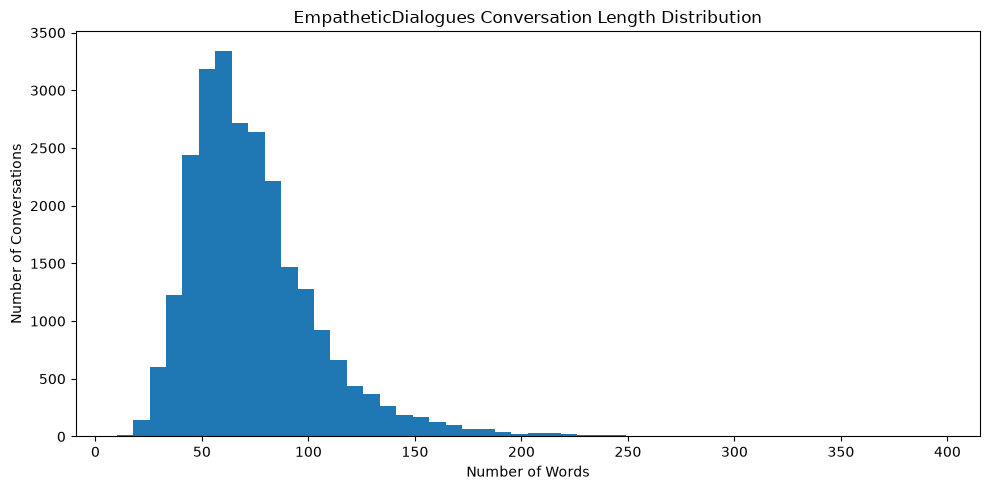

In [16]:
plt.figure(figsize=(10, 5))

plt.hist(topic_raw_df["word_count"],bins=50)

plt.title("EmpatheticDialogues Conversation Length Distribution")

plt.xlabel("Number of Words")
plt.ylabel("Number of Conversations")

plt.tight_layout()
plt.show()

In [17]:
# Inspect longest conversation
topic_raw_df.sort_values(by="word_count",ascending=False)[["conversation_id","word_count","clean_text"]].head()

,conversation_id,word_count,clean_text
12250,empathetic_hit:4330_conv:8660,396,Situation: Life can be really not a happy plac...
15104,empathetic_hit:5615_conv:11230,378,Situation: I got some fast food today and it w...
12345,empathetic_hit:4373_conv:8747,375,Situation: You know that feeling when loneline...
13568,empathetic_hit:4924_conv:9848,331,Situation: I had spent ages organising a lovel...
5405,empathetic_hit:124_conv:249,312,Situation: I had a girl that I was seeing one ...


**Define the topic keywords**

EmpatheticDialogues provides emotion-related labels but does not provide the custom topic labels required by EmoExpress.

Therefore, initial topic labels are generated using weak supervision.

Keyword rules are used to identify the primary topic discussed in each conversation. These labels are provisional and should be reviewed before
being treated as reliable training labels.

In [18]:
TOPIC_KEYWORDS = {
    "career_and_work": [
        "job",
        "jobs",
        "work",
        "working",
        "workplace",
        "office",
        "boss",
        "manager",
        "coworker",
        "colleague",
        "career",
        "interview",
        "promotion",
        "promoted",
        "fired",
        "laid off",
        "unemployed",
        "unemployment",
        "salary",
        "resume",
        "profession",
        "business",
        "company",
    ],

    "education": [
        "school",
        "college",
        "university",
        "class",
        "teacher",
        "professor",
        "student",
        "exam",
        "test",
        "quiz",
        "homework",
        "assignment",
        "degree",
        "study",
        "studying",
        "grade",
        "graduation",
        "campus",
        "course",
    ],

    "relationships": [
        "boyfriend",
        "girlfriend",
        "partner",
        "husband",
        "wife",
        "dating",
        "date",
        "relationship",
        "breakup",
        "broke up",
        "marriage",
        "married",
        "friend",
        "friends",
        "friendship",
        "best friend",
        "romantic",
        "divorce",
    ],

    "family": [
        "family",
        "mother",
        "father",
        "mom",
        "dad",
        "parent",
        "parents",
        "brother",
        "sister",
        "sibling",
        "daughter",
        "son",
        "child",
        "children",
        "grandmother",
        "grandfather",
        "grandparent",
        "relative",
        "uncle",
        "aunt",
        "cousin",
    ],

    "stress_and_anxiety": [
        "stress",
        "stressed",
        "stressful",
        "anxiety",
        "anxious",
        "nervous",
        "worried",
        "worry",
        "panic",
        "panicking",
        "overwhelmed",
        "pressure",
        "afraid",
        "fearful",
        "tense",
        "scared",
        "concerned",
    ],

    "grief_and_loss": [
        "died",
        "death",
        "passed away",
        "funeral",
        "grief",
        "grieving",
        "mourning",
        "loss",
        "lost someone",
        "lost my",
        "deceased",
        "dead",
        "memorial",
        "burial",
        "passed",
    ],

    "loneliness": [
        "lonely",
        "loneliness",
        "alone",
        "isolated",
        "isolation",
        "no friends",
        "left out",
        "excluded",
        "nobody",
        "no one cares",
        "by myself",
        "abandoned",
        "ignored",
    ],

    "self_confidence": [
        "confidence",
        "confident",
        "insecure",
        "insecurity",
        "worthless",
        "failure",
        "failed",
        "not good enough",
        "self-esteem",
        "self esteem",
        "embarrassed",
        "embarrassing",
        "ashamed",
        "ugly",
        "unattractive",
        "proud of myself",
        "doubt myself",
    ],

    "financial_concerns": [
        "money",
        "financial",
        "finances",
        "rent",
        "debt",
        "loan",
        "bill",
        "bills",
        "afford",
        "income",
        "bank",
        "budget",
        "expensive",
        "poor",
        "payment",
        "mortgage",
        "credit card",
        "paycheck",
        "cost",
    ],

    "health_and_wellness": [
        "health",
        "healthy",
        "doctor",
        "hospital",
        "sick",
        "ill",
        "illness",
        "pain",
        "medicine",
        "medical",
        "sleep",
        "exercise",
        "diet",
        "nutrition",
        "disease",
        "injury",
        "injured",
        "surgery",
        "treatment",
        "weight",
    ],

    "personal_growth": [
        "goal",
        "goals",
        "improve myself",
        "self-improvement",
        "self improvement",
        "habit",
        "motivation",
        "motivated",
        "future",
        "change my life",
        "personal growth",
        "become better",
        "learn from",
        "new beginning",
        "achievement",
        "accomplishment",
        "progress",
    ],

    "daily_life": [
        "shopping",
        "restaurant",
        "food",
        "cooking",
        "travel",
        "trip",
        "vacation",
        "weather",
        "weekend",
        "appointment",
        "bus",
        "train",
        "car",
        "movie",
        "music",
        "party",
        "game",
        "store",
        "concert",
        "birthday",
        "holiday",
    ],
}

## Create the topic-scoring function


In [19]:
def calculate_topic_scores(text: str) -> dict[str, int]:
    """
    Count keyword matches for every topic.

    Parameters
    ----------
    text: Conversation text.

    Returns
    -------
    dict: Mapping of topic names to keyword-match scores.
    """
    normalized_text = str(text).lower()

    scores = {}

    for topic, keywords in TOPIC_KEYWORDS.items():
        topic_score = 0

        for keyword in keywords:
            pattern = (r"\b"+ re.escape(keyword.lower()) + r"\b")

            matches = re.findall(pattern,normalized_text)

            topic_score += len(matches)

        scores[topic] = topic_score

    return scores

## Create the topic-assignment function


This function returns:

- Best topic
- Highest topic score
- Second-highest score
- Difference between the top two scores
- Whether the example is ambiguous

In [20]:
def assign_keyword_topic(text: str) -> dict:
    """
    Assign one primary topic using keyword scores.

    If no topic keywords are found, the example is assigned
    to general_support.
    """
    scores = calculate_topic_scores(text)

    sorted_scores = sorted(scores.items(),key=lambda item: item[1],reverse=True)

    best_topic, best_score = sorted_scores[0]

    second_best_topic, second_best_score = (sorted_scores[1] if len(sorted_scores) > 1 else ("general_support", 0))

    if best_score == 0:
        return {
            "topic": "general_support",
            "keyword_score": 0,
            "second_topic": None,
            "second_score": 0,
            "score_difference": 0,
            "is_ambiguous": True,
        }

    score_difference = (best_score - second_best_score)

    return {"topic": best_topic,
        "keyword_score": best_score,
        "second_topic": second_best_topic,
        "second_score": second_best_score,
        "score_difference": score_difference,
        "is_ambiguous": (score_difference == 0)}

In [21]:
# test the function
sample_text = ("I am worried that I may lose my job and I cannot afford my bills.")

assign_keyword_topic(sample_text)

{'topic': 'financial_concerns',
 'keyword_score': 2,
 'second_topic': 'career_and_work',
 'second_score': 1,
 'score_difference': 1,
 'is_ambiguous': False}

## Apply the topic-labeling function


In [22]:
keyword_label_results = (topic_raw_df["clean_text"].apply(assign_keyword_topic))

In [23]:
topic_raw_df["topic"] = (keyword_label_results.apply(lambda result: result["topic"]))

topic_raw_df["keyword_score"] = (keyword_label_results.apply(lambda result: result["keyword_score"]))

topic_raw_df["second_topic"] = (keyword_label_results.apply(lambda result: result["second_topic"]))
    
topic_raw_df["second_score"] = (keyword_label_results.apply(lambda result: result["second_score"]))

topic_raw_df["score_difference"] = (keyword_label_results.apply(lambda result: result["score_difference"]))
    
topic_raw_df["is_ambiguous"] = (keyword_label_results.apply( lambda result: result["is_ambiguous"]))

topic_raw_df.head(5)

,conversation_id,text,source,original_split,original_emotion,clean_text,word_count,topic,keyword_score,second_topic,second_score,score_difference,is_ambiguous
0,empathetic_hit:0_conv:0,Situation: I felt guilty when I was driving ho...,empathetic_dialogues,test,guilty,Situation: I felt guilty when I was driving ho...,123,general_support,0,NaN,0,0,True
1,empathetic_hit:0_conv:1,Situation: I remember going to the fireworks w...,empathetic_dialogues,train,sentimental,Situation: I remember going to the fireworks w...,105,relationships,9,loneliness,1,8,False
2,empathetic_hit:10000_conv:20000,Situation: My girlfriend got me a toad today! ...,empathetic_dialogues,train,surprised,Situation: My girlfriend got me a toad today! ...,54,relationships,2,career_and_work,0,2,False
3,empathetic_hit:10000_conv:20001,Situation: I really like the new paint job on ...,empathetic_dialogues,train,impressed,Situation: I really like the new paint job on ...,52,career_and_work,2,education,0,2,False
4,empathetic_hit:10001_conv:20002,Situation: I went to the skating rink all by m...,empathetic_dialogues,train,lonely,Situation: I went to the skating rink all by m...,83,relationships,3,loneliness,3,0,True


## Inspect the initial topic distribution


In [24]:
topic_distribution_df = (topic_raw_df["topic"].value_counts().rename_axis("topic").reset_index(name="count"))

topic_distribution_df["percentage"] = (topic_distribution_df["count"]/ topic_distribution_df["count"].sum()* 100)

topic_distribution_df

,topic,count,percentage
0,general_support,4416,17.770624
1,relationships,3693,14.861167
2,career_and_work,3564,14.342052
3,family,3488,14.036217
4,daily_life,3269,13.154930
5,education,2077,8.358149
6,stress_and_anxiety,1240,4.989940
7,financial_concerns,888,3.573441
8,health_and_wellness,791,3.183099
9,grief_and_loss,629,2.531187


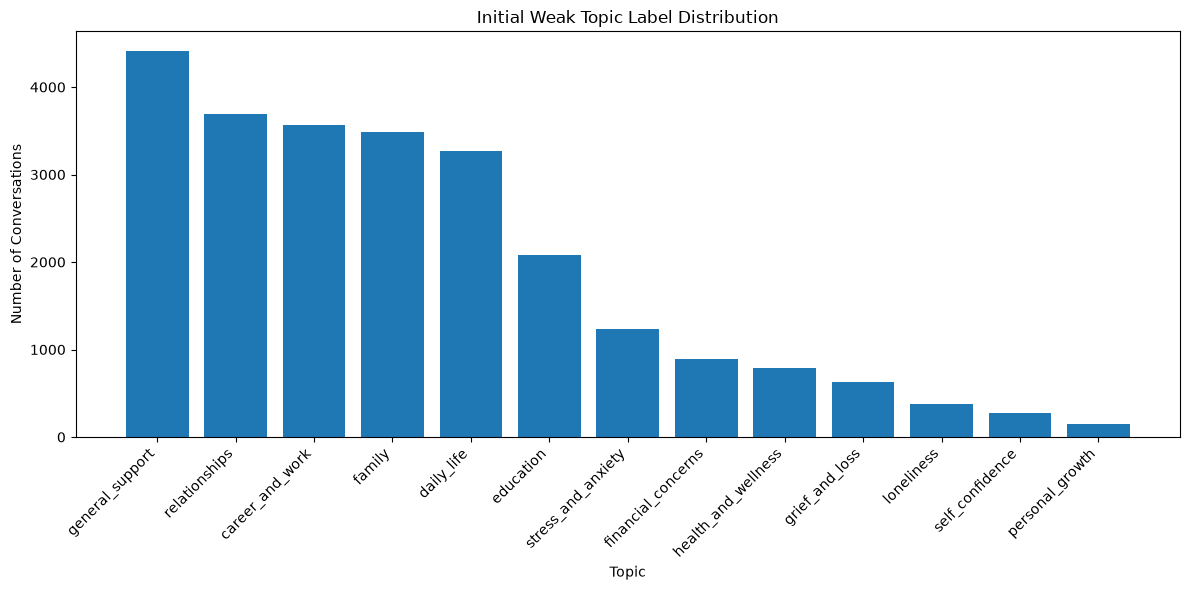

In [25]:
plt.figure(figsize=(12, 6))

plt.bar(topic_distribution_df["topic"],topic_distribution_df["count"])

plt.title("Initial Weak Topic Label Distribution")

plt.xlabel("Topic")
plt.ylabel("Number of Conversations")

plt.xticks(rotation=45,ha="right")

plt.tight_layout()
plt.show()

## Analyze keyword confidence


In [26]:
print("Total conversations:",len(topic_raw_df))

print("Conversations with keyword matches:",(topic_raw_df["keyword_score"] > 0 ).sum())

print("Conversations without keyword matches:",(topic_raw_df["keyword_score"] == 0).sum())

print("Ambiguous conversations:",topic_raw_df["is_ambiguous"].sum())

Total conversations: 24850
Conversations with keyword matches: 20434
Conversations without keyword matches: 4416
Ambiguous conversations: 7791


In [27]:
matched_percentage = ((topic_raw_df["keyword_score"] > 0).mean()* 100)

ambiguous_percentage = (topic_raw_df["is_ambiguous"].mean()* 100)

print(f"Keyword-match percentage: "f"{matched_percentage:.2f}%")

print(f"Ambiguous-label percentage: "f"{ambiguous_percentage:.2f}%")

Keyword-match percentage: 82.23%
Ambiguous-label percentage: 31.35%


## Display examples by topic


In [28]:
def display_topic_examples(dataframe: pd.DataFrame,topic: str,number_of_examples: int = 5) -> None:
    """
    Display random conversations assigned to a topic.
    """
    topic_dataframe = dataframe[dataframe["topic"] == topic]

    if topic_dataframe.empty:
        print(f"No examples found for: {topic}")
        return

    sample_size = min(number_of_examples,len(topic_dataframe))

    sample_dataframe = (topic_dataframe.sample(n=sample_size,random_state=RANDOM_STATE))

    for example_number, (_, row) in enumerate(sample_dataframe.iterrows(),start=1):
        print(f"\nExample {example_number}")

        print(f"Topic: {row['topic']}")
            

        print(f"Keyword score: {row['keyword_score']}")
            

        print(f"Second topic: {row['second_topic']}")
            

        print(f"Original emotion: {row.get('original_emotion', 'N/A')}")
           

        print(row["clean_text"])

        print("-" * 100)

In [29]:
display_topic_examples(dataframe=topic_raw_df, topic="career_and_work", number_of_examples=3)


Example 1
Topic: career_and_work
Keyword score: 3
Second topic: education
Original emotion: proud
Situation: I was proud when my brother graduated college. He had to work hard but he got through it. Conversation: My little brother graduated not too long ago. He had to work hard but made it through it. He did! He actually just started a new job that he loves and is related to his degree.
----------------------------------------------------------------------------------------------------

Example 2
Topic: career_and_work
Keyword score: 2
Second topic: relationships
Original emotion: jealous
Situation: I'm unemployed and struggling right now. I feel really bad when people talk to me about their new houses and clothes and stuff_comma_ even though they're not trying to be mean Conversation: I'm unemployed and struggling right now. I feel really bad when people talk to me about their new stuff_comma_ even though they're not trying to be mean yeah! I just want to be able to support myself an

In [30]:
display_topic_examples(dataframe=topic_raw_df, topic="relationships", number_of_examples=3)


Example 1
Topic: relationships
Keyword score: 4
Second topic: education
Original emotion: hopeful
Situation: My best friend is returning to college after an academic suspension. I hope that this semester will be different since I'm taking the same classes as her. Conversation: My best friend is finally able to come back to school after an academic suspension. That's good! Was there a reason for the suspension? She had failed too many classes. We're in the same classes this semester_comma_ so that should help keep her on track. It'll be good for her to have your support_comma_ so hopefully she'll do better this semester. Thanks! I hope so as well.
----------------------------------------------------------------------------------------------------

Example 2
Topic: relationships
Keyword score: 2
Second topic: daily_life
Original emotion: impressed
Situation: I came home from grocery shopping to find that my husband had cleaned the entire house up and started dinner. I was amazed. Conver

In [31]:
display_topic_examples(dataframe=topic_raw_df, topic="stress_and_anxiety", number_of_examples=3)


Example 1
Topic: stress_and_anxiety
Keyword score: 2
Second topic: career_and_work
Original emotion: afraid
Situation: Our dog started barking a lot in the middle of the night. I was looking out the windows trying to see if someone was out there. It was too dark to see anything. Conversation: I'm so tired. I was awake for hours last night. Oh_comma_ sorry to hear that. I was under a lot of stress. What happened to you? Our dog was baking and I couldn't see what he was all upset about. He never bark like that. Oh no_comma_ sorry hope it wasn't a snake. My hound dog is alwayd barking. What was stressful for you? Yah_comma_ lost my job and trying to find a new one.
----------------------------------------------------------------------------------------------------

Example 2
Topic: stress_and_anxiety
Keyword score: 3
Second topic: relationships
Original emotion: afraid
Situation: I am scared of how I will die. Conversation: I am scared of how I will die. I worry about that too occasional

## Inspect ambiguous labels


In [32]:
ambiguous_df = topic_raw_df[topic_raw_df["is_ambiguous"]].copy()
    
print( "Ambiguous examples:",len(ambiguous_df))

Ambiguous examples: 7791


In [33]:
ambiguous_columns = ["clean_text","topic","keyword_score","second_topic","second_score","original_emotion"]

available_ambiguous_columns = [ column for column in ambiguous_columns if column in ambiguous_df.columns]

ambiguous_df[available_ambiguous_columns].sample(n=min(10,len(ambiguous_df)),random_state=RANDOM_STATE)

,clean_text,topic,keyword_score,second_topic,second_score,original_emotion
4737,Situation: I really miss my man_comma_ he went...,career_and_work,2,daily_life,2,sentimental
18569,Situation: The sun is shining and I ahve no pl...,general_support,0,NaN,0,content
17013,Situation: I cant wait for the football season...,general_support,0,NaN,0,excited
3465,Situation: The first time my brother was comin...,education,2,family,2,excited
323,Situation: This weekend the family is going to...,family,2,financial_concerns,2,anticipating
17158,Situation: i dont like hospitals Conversation:...,stress_and_anxiety,1,health_and_wellness,1,afraid
1647,Situation: One time a person offered to drive ...,general_support,0,NaN,0,grateful
19463,Situation: I really do not like the new text a...,general_support,0,NaN,0,angry
24783,Situation: I'm ready to cook tonight! Conversa...,general_support,0,NaN,0,prepared
20559,Situation: Recently my son got very good news ...,family,2,health_and_wellness,2,hopeful


**Export a manual-review sample**

Because the initial topic labels are produced using keyword rules, a stratified sample is exported for manual inspection.

In [34]:
MANUAL_REVIEW_SAMPLES_PER_TOPIC = 20

In [35]:
manual_review_dataframes = []

for topic, topic_dataframe in (topic_raw_df.groupby("topic")):
    sample_size = min(MANUAL_REVIEW_SAMPLES_PER_TOPIC,len(topic_dataframe))

    sampled_topic_dataframe = (topic_dataframe.sample(n=sample_size,random_state=RANDOM_STATE))

    manual_review_dataframes.append(sampled_topic_dataframe)

manual_review_df = pd.concat(manual_review_dataframes,ignore_index=True)

manual_review_df["reviewed_topic"] = ""

manual_review_df["is_correct"] = ""

manual_review_df["review_notes"] = ""

In [36]:
MANUAL_REVIEW_PATH = (OUTPUT_DIR/ "topic_label_manual_review.csv")

manual_review_df.to_csv(MANUAL_REVIEW_PATH,index=False)

print("Manual-review file saved to:",MANUAL_REVIEW_PATH)

print("Number of review examples:",len(manual_review_df))

Manual-review file saved to: D:\FullStack_Academic\Final Capstone\EmoExpress\outputs\topic_classifier\topic_label_manual_review.csv
Number of review examples: 260


## Filter the labeled dataset


In [37]:
matched_non_ambiguous_df = topic_raw_df[(topic_raw_df["keyword_score"] >= 1) & (~topic_raw_df["is_ambiguous"])].copy()

print("Matched non-ambiguous examples:",matched_non_ambiguous_df.shape)

Matched non-ambiguous examples: (17059, 13)


In [38]:
# Select a controlled sample of unmatched examples for general_support:
general_support_df = topic_raw_df[topic_raw_df["keyword_score"] == 0].copy()

general_support_df["topic"] = ("general_support")

MAX_GENERAL_SUPPORT_SAMPLES = 2_500

if (len(general_support_df) > MAX_GENERAL_SUPPORT_SAMPLES):
    general_support_df = (general_support_df.sample(n=MAX_GENERAL_SUPPORT_SAMPLES,random_state=RANDOM_STATE))

print("General-support examples:",general_support_df.shape)

General-support examples: (2500, 13)


In [39]:
# combine the selected data
labeled_df = pd.concat([matched_non_ambiguous_df,general_support_df],ignore_index=True)

labeled_df = (labeled_df.drop_duplicates(subset=["clean_text"]).reset_index(drop=True))

print("Labeled dataset shape:",labeled_df.shape)

Labeled dataset shape: (19559, 13)


## Check class sizes


In [40]:
class_counts = (labeled_df["topic"].value_counts().reindex(TOPIC_LABELS,fill_value=0))

class_counts

topic
career_and_work        2736
education              1587
relationships          2866
family                 2824
stress_and_anxiety      993
grief_and_loss          570
loneliness              332
self_confidence         233
financial_concerns      796
health_and_wellness     720
personal_growth         133
daily_life             3269
general_support        2500
Name: count, dtype: int64

In [41]:
MINIMUM_CLASS_SIZE = 20

small_classes = class_counts[class_counts < MINIMUM_CLASS_SIZE]

if small_classes.empty:
    print(f"All topic classes contain at least {MINIMUM_CLASS_SIZE} examples.")
else:
    print("The following topic classes contain too few examples:")
    print(small_classes)

All topic classes contain at least 20 examples.


In [42]:
valid_topics = class_counts[class_counts >= MINIMUM_CLASS_SIZE].index.tolist()

labeled_df = labeled_df[labeled_df["topic"].isin(valid_topics)].reset_index(drop=True)

print("Topics retained:",valid_topics)

print("Dataset shape:",labeled_df.shape)

Topics retained: ['career_and_work', 'education', 'relationships', 'family', 'stress_and_anxiety', 'grief_and_loss', 'loneliness', 'self_confidence', 'financial_concerns', 'health_and_wellness', 'personal_growth', 'daily_life', 'general_support']
Dataset shape: (19559, 13)


## Cap very large dataset


In [43]:
MAX_SAMPLES_PER_TOPIC = 3_000

balanced_dataframes = []

for topic, topic_dataframe in (labeled_df.groupby("topic")):
    if (len(topic_dataframe) > MAX_SAMPLES_PER_TOPIC):
        topic_dataframe = (topic_dataframe.sample(n=MAX_SAMPLES_PER_TOPIC,random_state=RANDOM_STATE))

    balanced_dataframes.append(topic_dataframe)

balanced_df = pd.concat(balanced_dataframes,ignore_index=True)

balanced_df = (balanced_df.sample(frac=1,random_state=RANDOM_STATE).reset_index(drop=True))

print("Balanced dataset shape:",balanced_df.shape)

balanced_df["topic"].value_counts()

Balanced dataset shape: (19290, 13)


topic
daily_life             3000
relationships          2866
family                 2824
career_and_work        2736
general_support        2500
education              1587
stress_and_anxiety      993
financial_concerns      796
health_and_wellness     720
grief_and_loss          570
loneliness              332
self_confidence         233
personal_growth         133
Name: count, dtype: int64

In [44]:
balanced_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19290 entries, 0 to 19289
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   conversation_id   19290 non-null  str  
 1   text              19290 non-null  str  
 2   source            19290 non-null  str  
 3   original_split    19290 non-null  str  
 4   original_emotion  19290 non-null  str  
 5   clean_text        19290 non-null  str  
 6   word_count        19290 non-null  int64
 7   topic             19290 non-null  str  
 8   keyword_score     19290 non-null  int64
 9   second_topic      16790 non-null  str  
 10  second_score      19290 non-null  int64
 11  score_difference  19290 non-null  int64
 12  is_ambiguous      19290 non-null  bool 
dtypes: bool(1), int64(4), str(8)
memory usage: 18.0 MB


## Visualize the final training distribution


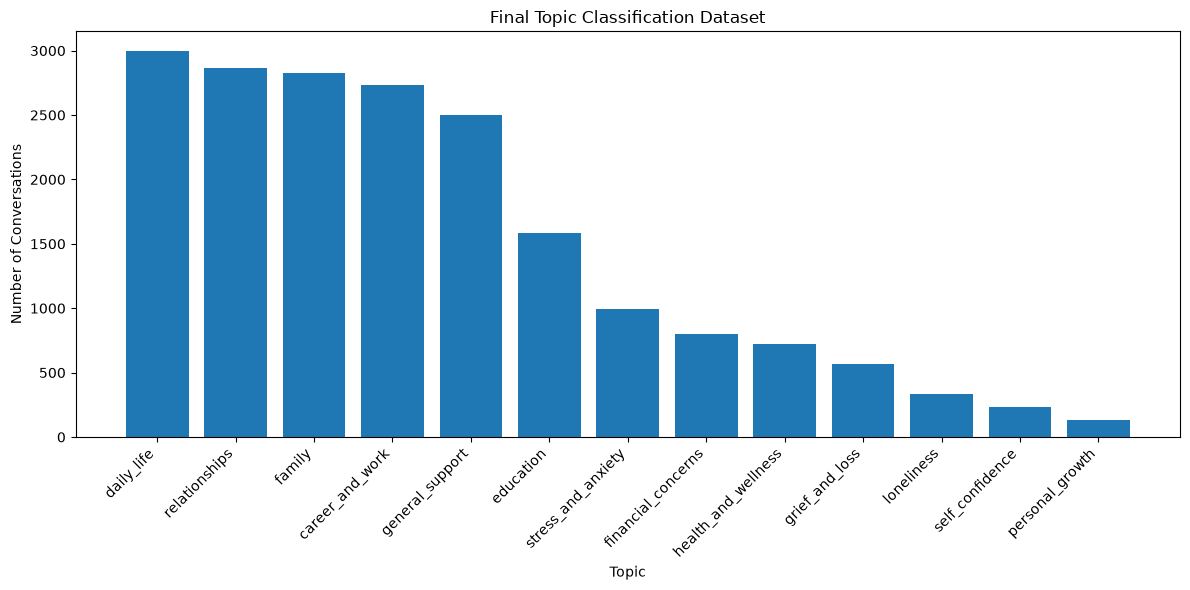

In [45]:
balanced_topic_counts = (balanced_df["topic"].value_counts().sort_values(ascending=False))

plt.figure(figsize=(12, 6))

plt.bar(balanced_topic_counts.index,balanced_topic_counts.values)

plt.title("Final Topic Classification Dataset")

plt.xlabel("Topic")
plt.ylabel("Number of Conversations")

plt.xticks(rotation=45,ha="right")

plt.tight_layout()
plt.show()

## Encode labels and save the prepared dataset


In [46]:
label_encoder = LabelEncoder()
balanced_df["label"] = label_encoder.fit_transform(balanced_df["topic"])

TOPIC_NAMES = list(label_encoder.classes_)
NUM_LABELS = len(TOPIC_NAMES)

print("Number of labels:", NUM_LABELS)
print(dict(enumerate(TOPIC_NAMES)))


Number of labels: 13
{0: 'career_and_work', 1: 'daily_life', 2: 'education', 3: 'family', 4: 'financial_concerns', 5: 'general_support', 6: 'grief_and_loss', 7: 'health_and_wellness', 8: 'loneliness', 9: 'personal_growth', 10: 'relationships', 11: 'self_confidence', 12: 'stress_and_anxiety'}


In [47]:
LABELED_DATA_PATH = (
    PROCESSED_DATA_DIR / "empathetic_topic_classification_dataset.csv"
)
COMPACT_DATA_PATH = (
    PROCESSED_DATA_DIR / "empathetic_topic_text_labels.csv"
)

balanced_df.to_csv(LABELED_DATA_PATH, index=False)

compact_topic_df = balanced_df[
    ["text", "clean_text", "topic", "original_split", "label"]
].copy()
compact_topic_df.to_csv(COMPACT_DATA_PATH, index=False)

print("Full dataset saved to:", LABELED_DATA_PATH)
print("Compact dataset saved to:", COMPACT_DATA_PATH)
print("Compact dataset shape:", compact_topic_df.shape)
display(compact_topic_df.head())


Full dataset saved to: D:\FullStack_Academic\Final Capstone\EmoExpress\data\processed\empathetic_topic_classification_dataset.csv
Compact dataset saved to: D:\FullStack_Academic\Final Capstone\EmoExpress\data\processed\empathetic_topic_text_labels.csv
Compact dataset shape: (19290, 5)


,text,clean_text,topic,original_split,label
0,Situation: A Groundhog made his way under my d...,Situation: A Groundhog made his way under my d...,family,train,3
1,Situation: The final exam for my Linear Algebr...,Situation: The final exam for my Linear Algebr...,education,train,2
2,Situation: I'm always expecting new money oppo...,Situation: I'm always expecting new money oppo...,career_and_work,train,0
3,Situation: A man keeps asking me out on a date...,Situation: A man keeps asking me out on a date...,relationships,train,10
4,Situation: Yesterday was sure shocking to watc...,Situation: Yesterday was sure shocking to watc...,daily_life,train,1


## Split the dataset


In [48]:
train_df, temporary_df = train_test_split(balanced_df,
                                        test_size=0.30,
                                        random_state=RANDOM_STATE,
                                        stratify=balanced_df["topic"])

validation_df, test_df = train_test_split(temporary_df,
                                        test_size=0.50,
                                        random_state=RANDOM_STATE,
                                        stratify=temporary_df["topic"])

In [49]:
train_df = train_df.reset_index(drop=True)

validation_df = validation_df.reset_index(drop=True)

test_df = test_df.reset_index(drop=True)

print("Training set:",train_df.shape)

print("Validation set:",validation_df.shape)

print("Test set:",test_df.shape)

Training set: (13503, 14)
Validation set: (2893, 14)
Test set: (2894, 14)


## Check split distributions


In [50]:
def display_split_distribution(dataframe: pd.DataFrame,split_name: str) -> None:
    """
    Display topic counts and proportions for a split.
    """
    counts = (dataframe["topic"].value_counts().reindex(TOPIC_NAMES,fill_value=0))

    proportions = (dataframe["topic"].value_counts(normalize=True).reindex(TOPIC_NAMES,fill_value=0))

    output_df = pd.DataFrame({"count": counts,"proportion": proportions})

    print(f"\n{split_name}")
    print("-" * 60)
    print(output_df)

In [51]:
display_split_distribution(train_df,"Training Set")


Training Set
------------------------------------------------------------
                     count  proportion
topic                                 
career_and_work       1915    0.141820
daily_life            2100    0.155521
education             1111    0.082278
family                1977    0.146412
financial_concerns     557    0.041250
general_support       1750    0.129601
grief_and_loss         399    0.029549
health_and_wellness    504    0.037325
loneliness             233    0.017255
personal_growth         93    0.006887
relationships         2006    0.148560
self_confidence        163    0.012071
stress_and_anxiety     695    0.051470


In [52]:

display_split_distribution(validation_df,"Validation Set")


Validation Set
------------------------------------------------------------
                     count  proportion
topic                                 
career_and_work        410    0.141721
daily_life             450    0.155548
education              238    0.082268
family                 423    0.146215
financial_concerns     119    0.041134
general_support        375    0.129623
grief_and_loss          86    0.029727
health_and_wellness    108    0.037331
loneliness              50    0.017283
personal_growth         20    0.006913
relationships          430    0.148635
self_confidence         35    0.012098
stress_and_anxiety     149    0.051504


In [53]:

display_split_distribution(test_df,"Test Set")


Test Set
------------------------------------------------------------
                     count  proportion
topic                                 
career_and_work        411    0.142018
daily_life             450    0.155494
education              238    0.082239
family                 424    0.146510
financial_concerns     120    0.041465
general_support        375    0.129578
grief_and_loss          85    0.029371
health_and_wellness    108    0.037319
loneliness              49    0.016932
personal_growth         20    0.006911
relationships          430    0.148583
self_confidence         35    0.012094
stress_and_anxiety     149    0.051486


In [54]:
# Save the splits
TRAIN_DATA_PATH = (PROCESSED_DATA_DIR/ "topic_train.csv")

VALIDATION_DATA_PATH = (PROCESSED_DATA_DIR/ "topic_validation.csv")

TEST_DATA_PATH = (PROCESSED_DATA_DIR/ "topic_test.csv")

train_df.to_csv(TRAIN_DATA_PATH,index=False)

validation_df.to_csv(VALIDATION_DATA_PATH,index=False)

test_df.to_csv(TEST_DATA_PATH,index=False)

print("Dataset splits saved successfully.")

Dataset splits saved successfully.


**Define the evaluation function**

This is a single-label, multi-class classification problem.

The models are evaluated using:

- Accuracy
- Macro precision
- Macro recall
- Macro F1
- Weighted precision
- Weighted recall
- Weighted F1
- Training time
- Inference time

Macro F1 is the main model-selection metric because it gives equal importance to every topic class.

In [55]:
def evaluate_topic_model(y_true,
                            y_pred,
                            model_name: str,
                            training_time_seconds: float,
                            inference_time_seconds: float) -> dict:
    """
    Evaluate a single-label topic classifier.
    """
    accuracy = accuracy_score(y_true,y_pred)

    (macro_precision,macro_recall,macro_f1, _,) = precision_recall_fscore_support(y_true, y_pred,average="macro",zero_division=0)
                                               
    (weighted_precision,weighted_recall,weighted_f1,_,) = precision_recall_fscore_support(y_true,y_pred,average="weighted",zero_division=0)

    print(f"\n{model_name}")
    print("=" * 80)

    print(classification_report(y_true,y_pred,labels=TOPIC_NAMES,zero_division=0))

    return {
        "model": model_name,
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
        "training_time_seconds": (training_time_seconds),
        "inference_time_seconds": (inference_time_seconds)}

In [56]:
topic_model_results = []

# Model 1: TF-IDF with Logistic Regression

This model provides a traditional machine-learning baseline.

TF-IDF represents each conversation using unigram and bigram features.
Logistic Regression then predicts one primary topic.

In [57]:
logistic_regression_pipeline = Pipeline(steps=
        [("tfidf",TfidfVectorizer(max_features=20_000, ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True, lowercase=True)),
        ("classifier",LogisticRegression(max_iter=1_000, class_weight="balanced", random_state=RANDOM_STATE))])

logistic_training_start = (time.perf_counter())

logistic_regression_pipeline.fit(train_df["clean_text"],train_df["topic"])

logistic_training_time = (time.perf_counter() - logistic_training_start)

print("Training time:",f"{logistic_training_time:.2f} seconds")

logistic_inference_start = (time.perf_counter())

logistic_predictions = (logistic_regression_pipeline.predict(test_df["clean_text"]))

logistic_inference_time = (time.perf_counter() - logistic_inference_start)

print(f"Inference time: {logistic_inference_time:.4f} seconds")

logistic_metrics = evaluate_topic_model(y_true=test_df["topic"],
                                        y_pred=logistic_predictions,
                                        model_name=("TF-IDF + Logistic Regression"),
                                        training_time_seconds=(logistic_training_time),
                                        inference_time_seconds=(logistic_inference_time))

topic_model_results.append(logistic_metrics)

Training time: 5.15 seconds
Inference time: 0.2969 seconds

TF-IDF + Logistic Regression
                     precision    recall  f1-score   support

    career_and_work       0.94      0.86      0.90       411
         daily_life       0.92      0.83      0.87       450
          education       0.91      0.89      0.90       238
             family       0.89      0.87      0.88       424
 financial_concerns       0.80      0.80      0.80       120
    general_support       0.66      0.80      0.72       375
     grief_and_loss       0.87      0.84      0.85        85
health_and_wellness       0.74      0.81      0.78       108
         loneliness       0.81      0.78      0.79        49
    personal_growth       0.78      0.35      0.48        20
      relationships       0.89      0.92      0.90       430
    self_confidence       0.70      0.74      0.72        35
 stress_and_anxiety       0.79      0.79      0.79       149

           accuracy                           0.85     

# Model 2: TF-IDF with Linear SVM

Linear SVM is often effective for high-dimensional text-classification problems.

It uses the same TF-IDF features as Logistic Regression but learns a linear decision boundary between the topic classes.

In [59]:
linear_svm_pipeline = Pipeline(steps=[
        ("tfidf",TfidfVectorizer(max_features=20_000,ngram_range=(1, 2),min_df=2,max_df=0.95,sublinear_tf=True,lowercase=True)),
        ("classifier",LinearSVC(class_weight="balanced",random_state=RANDOM_STATE))])

svm_training_start = (time.perf_counter())

linear_svm_pipeline.fit(train_df["clean_text"],train_df["topic"])

svm_training_time = (time.perf_counter() - svm_training_start)

print("Training time:",f"{svm_training_time:.2f} seconds")

svm_inference_start = (time.perf_counter())

svm_predictions = (linear_svm_pipeline.predict(test_df["clean_text"]))

svm_inference_time = (time.perf_counter() - svm_inference_start)

print("Inference time:",f"{svm_inference_time:.4f} seconds")

svm_metrics = evaluate_topic_model(y_true=test_df["topic"], 
                                   y_pred=svm_predictions, 
                                    model_name="TF-IDF + Linear SVM",
                                    training_time_seconds=(svm_training_time),
                                    inference_time_seconds=(svm_inference_time))

topic_model_results.append(svm_metrics)

Training time: 3.10 seconds
Inference time: 0.3806 seconds

TF-IDF + Linear SVM
                     precision    recall  f1-score   support

    career_and_work       0.94      0.93      0.94       411
         daily_life       0.94      0.91      0.92       450
          education       0.91      0.93      0.92       238
             family       0.92      0.93      0.92       424
 financial_concerns       0.89      0.84      0.87       120
    general_support       0.73      0.85      0.79       375
     grief_and_loss       0.93      0.93      0.93        85
health_and_wellness       0.90      0.78      0.84       108
         loneliness       0.86      0.78      0.82        49
    personal_growth       0.89      0.40      0.55        20
      relationships       0.94      0.97      0.95       430
    self_confidence       0.79      0.63      0.70        35
 stress_and_anxiety       0.91      0.79      0.84       149

           accuracy                           0.89      2894
   


# Model 3: Fine-Tuned DistilBERT

DistilBERT is fine-tuned as a single-label, multi-class topic classifier.

Unlike the EmoExpress emotion classifier, this model uses:

- One topic label per conversation
- Integer class labels
- Softmax output
- Multi-class cross-entropy loss

In [61]:
transformer_train_df = train_df[["clean_text","label"]].rename(columns={"clean_text": "text"})

transformer_validation_df = validation_df[["clean_text","label"]].rename(columns={"clean_text": "text"})

transformer_test_df = test_df[["clean_text","label"]].rename(columns={"clean_text": "text"})

topic_dataset = DatasetDict({"train": Dataset.from_pandas(transformer_train_df,preserve_index=False),
                        "validation": Dataset.from_pandas(transformer_validation_df,preserve_index=False),
                           "test": Dataset.from_pandas(transformer_test_df,preserve_index=False)})
topic_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 13503
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2893
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2894
    })
})

Load the DistilBERT tokenizer

In [62]:
DISTILBERT_MODEL_NAME = ("distilbert-base-uncased")

topic_tokenizer = (AutoTokenizer.from_pretrained(DISTILBERT_MODEL_NAME))

topic_tokenizer

BertTokenizer(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})


Tokenize the datasets

In [63]:
MAX_TOKEN_LENGTH = 256
def tokenize_topic_batch(batch):
    """
    Tokenize a batch of topic-classification examples.
    """
    return topic_tokenizer(batch["text"],truncation=True,max_length=MAX_TOKEN_LENGTH)

tokenized_topic_dataset = (topic_dataset.map(tokenize_topic_batch,batched=True))

tokenized_topic_dataset

Map:   0%|          | 0/13503 [00:00<?, ? examples/s]

Map:   0%|          | 0/2893 [00:00<?, ? examples/s]

Map:   0%|          | 0/2894 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 13503
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2893
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2894
    })
})

Define the DistilBERT label mappings

In [64]:
id_to_label = {label_id: topic_name for label_id, topic_name in enumerate(TOPIC_NAMES)}

label_to_id = {topic_name: label_id for label_id, topic_name in (id_to_label.items())}

print(id_to_label)

{0: 'career_and_work', 1: 'daily_life', 2: 'education', 3: 'family', 4: 'financial_concerns', 5: 'general_support', 6: 'grief_and_loss', 7: 'health_and_wellness', 8: 'loneliness', 9: 'personal_growth', 10: 'relationships', 11: 'self_confidence', 12: 'stress_and_anxiety'}


Load DistilBERT

In [65]:
distilbert_topic_model = (AutoModelForSequenceClassification.from_pretrained(DISTILBERT_MODEL_NAME,
                                                                            num_labels=NUM_LABELS,
                                                                            id2label=id_to_label,
                                                                            label2id=label_to_id))

distilbert_topic_model.to(DEVICE)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (ffn): FFN(
            (dropout): Dropout(

A warning about newly initialized classifier weights is expected. The new classification head must be trained on your topic labels.

Create the data collator

In [66]:
topic_data_collator = (DataCollatorWithPadding(tokenizer=topic_tokenizer))

Define DistilBERT metrics

In [67]:
def compute_transformer_topic_metrics(evaluation_prediction) -> dict:
    """
    Compute topic-classification metrics for DistilBERT.
    """
    logits, labels = evaluation_prediction

    predictions = np.argmax(logits,axis=-1)

    accuracy = accuracy_score(labels,predictions)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(labels, predictions, average="macro", zero_division=0)

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(labels, predictions, average="weighted", zero_division=0)

    return {"accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": (weighted_precision),
        "weighted_recall": (weighted_recall),
        "weighted_f1": weighted_f1}

Configure DistilBERT training

In [68]:
DISTILBERT_OUTPUT_DIR = (MODEL_DIR/ "distilbert_training")

In [69]:
training_arguments = TrainingArguments(output_dir=str(DISTILBERT_OUTPUT_DIR),
                                        learning_rate=2e-5,
                                        per_device_train_batch_size=16,
                                        per_device_eval_batch_size=32,
                                        num_train_epochs=3,
                                        weight_decay=0.01,
                                        eval_strategy="epoch",
                                        save_strategy="epoch",
                                        logging_strategy="steps",
                                        logging_steps=100,
                                        load_best_model_at_end=True,
                                        metric_for_best_model="macro_f1",
                                        greater_is_better=True,
                                        save_total_limit=2,
                                        report_to="none",
                                        seed=RANDOM_STATE,
                                        fp16=torch.cuda.is_available())

Create the Trainer

In [70]:
topic_trainer = Trainer(model=distilbert_topic_model,
                        args=training_arguments,
                        train_dataset=(tokenized_topic_dataset["train"]),
                        eval_dataset=(tokenized_topic_dataset["validation"]),
                        processing_class=topic_tokenizer,
                        data_collator=topic_data_collator,
                        compute_metrics=(compute_transformer_topic_metrics),
                        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)])

Train DistilBERT

In [71]:
distilbert_training_start = time.perf_counter()
topic_training_output = topic_trainer.train()
distilbert_training_time = time.perf_counter() - distilbert_training_start

print(f"DistilBERT training time: {distilbert_training_time:.2f} seconds")

d:\FullStack_Academic\Final Capstone\EmoExpress\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,0.381732,0.304836,0.925683,0.837968,0.794261,0.799207,0.921499,0.925683,0.920345
2,0.123741,0.172752,0.957484,0.953532,0.884716,0.907202,0.957972,0.957484,0.956311
3,0.088407,0.153387,0.963705,0.955961,0.905417,0.924543,0.963776,0.963705,0.963012


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

d:\FullStack_Academic\Final Capstone\EmoExpress\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

d:\FullStack_Academic\Final Capstone\EmoExpress\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT training time: 23121.15 seconds


Evaluate DistilBERT

In [72]:
distilbert_inference_start = (time.perf_counter())

distilbert_prediction_output = (topic_trainer.predict(tokenized_topic_dataset["test"]))

distilbert_inference_time = (time.perf_counter() - distilbert_inference_start)

print("DistilBERT inference time:",f"{distilbert_inference_time:.2f} seconds")

distilbert_logits = (distilbert_prediction_output.predictions)

distilbert_true_labels = (distilbert_prediction_output.label_ids)

distilbert_predicted_labels = (np.argmax(distilbert_logits,axis=-1,))

distilbert_true_topics = (label_encoder.inverse_transform(distilbert_true_labels))

distilbert_predicted_topics = (label_encoder.inverse_transform(distilbert_predicted_labels))

distilbert_metrics = evaluate_topic_model(y_true=distilbert_true_topics,
                                        y_pred=distilbert_predicted_topics,
                                        model_name=("Fine-Tuned DistilBERT"),
                                        training_time_seconds=(distilbert_training_time),
                                        inference_time_seconds=(distilbert_inference_time))

topic_model_results.append(distilbert_metrics)

d:\FullStack_Academic\Final Capstone\EmoExpress\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


DistilBERT inference time: 445.67 seconds

Fine-Tuned DistilBERT
                     precision    recall  f1-score   support

    career_and_work       0.98      0.98      0.98       411
         daily_life       0.98      0.99      0.98       450
          education       0.95      0.98      0.97       238
             family       0.99      0.98      0.98       424
 financial_concerns       0.95      0.97      0.96       120
    general_support       0.95      0.96      0.96       375
     grief_and_loss       0.94      1.00      0.97        85
health_and_wellness       0.99      0.95      0.97       108
         loneliness       0.89      0.82      0.85        49
    personal_growth       1.00      0.35      0.52        20
      relationships       0.99      0.98      0.99       430
    self_confidence       0.83      0.83      0.83        35
 stress_and_anxiety       0.93      0.94      0.94       149

           accuracy                           0.97      2894
          macro av

# Model 4: Zero-Shot DeBERTa

This benchmark uses a pretrained DeBERTa natural-language-inference model
without fine-tuning it on the EmpatheticDialogues topic dataset.

The thirteen EmoExpress topics are supplied as candidate labels. The model
scores each test conversation against those labels and selects one primary
topic. Because the model is not trained in this notebook, its training time is
recorded as `0.0` seconds.


In [74]:
ZERO_SHOT_MODEL_NAME = ("MoritzLaurer/deberta-v3-base-zeroshot-v1.1-all-33")

zero_shot_device = 0 if torch.cuda.is_available() else -1

zero_shot_topic_classifier = pipeline(task="zero-shot-classification",
                                        model=ZERO_SHOT_MODEL_NAME,
                                        device=zero_shot_device)


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

## Prepare candidate labels

Spaces are used instead of underscores because they form more natural
hypothesis sentences for zero-shot classification. Predictions are converted
back to the original topic names before evaluation.


In [75]:
zero_shot_candidate_labels = [topic_name.replace("_", " ") for topic_name in TOPIC_NAMES]

candidate_label_to_topic = {candidate_label: topic_name for candidate_label, topic_name 
                                                            in zip(zero_shot_candidate_labels,TOPIC_NAMES)}

print("Zero-shot candidate labels:")
print(zero_shot_candidate_labels)


Zero-shot candidate labels:
['career and work', 'daily life', 'education', 'family', 'financial concerns', 'general support', 'grief and loss', 'health and wellness', 'loneliness', 'personal growth', 'relationships', 'self confidence', 'stress and anxiety']


## Evaluate zero-shot DeBERTa


The full test set is taking far too long on CPU, evaluate Zero-Shot DeBERTa on a reproducible sample instead.

In [ ]:
# Take a stratified sample sample from the test set
ZERO_SHOT_SAMPLE_SIZE = 200

_, zero_shot_sample_df = train_test_split(test_df,
                                        test_size=min(ZERO_SHOT_SAMPLE_SIZE, len(test_df)),
                                        stratify=test_df["topic"],
                                        random_state=42)

zero_shot_sample_df = zero_shot_sample_df.reset_index(drop=True)

print(zero_shot_sample_df["topic"].value_counts().sort_index())

topic
career_and_work        28
daily_life             31
education              17
family                 29
financial_concerns      8
general_support        26
grief_and_loss          6
health_and_wellness     8
loneliness              3
personal_growth         1
relationships          30
self_confidence         3
stress_and_anxiety     10
Name: count, dtype: int64


In [79]:
print("Full test set size:", len(test_df))
print("Zero-shot evaluation sample size:", len(zero_shot_sample_df))

Full test set size: 2894
Zero-shot evaluation sample size: 200


In [81]:
# Prepare text
zero_shot_test_texts = zero_shot_sample_df["clean_text"].tolist()

In [82]:
# Measure inference time
zero_shot_inference_start = time.perf_counter()

zero_shot_outputs = zero_shot_topic_classifier(zero_shot_test_texts,
                                                candidate_labels=zero_shot_candidate_labels,
                                                hypothesis_template="This text is mainly about {}.",
                                                multi_label=False,
                                                batch_size=8,
                                                truncation=True)

zero_shot_inference_time = (time.perf_counter() - zero_shot_inference_start)


# Convert zero-shot labels back to project topic names
zero_shot_predictions = [candidate_label_to_topic[output["labels"][0]]
                                                             for output in zero_shot_outputs]


print(f"Zero-shot DeBERTa inference time "
    f"for {len(zero_shot_sample_df)} samples: "
    f"{zero_shot_inference_time:.2f} seconds")


# Evaluate
zero_shot_metrics = evaluate_topic_model(
    y_true=zero_shot_sample_df["topic"],
    y_pred=zero_shot_predictions,
    model_name=f"Zero-Shot DeBERTa ({len(zero_shot_sample_df)} samples)",
    training_time_seconds=0.0,
    inference_time_seconds=zero_shot_inference_time,
)


topic_model_results.append(zero_shot_metrics)

Zero-shot DeBERTa inference time for 200 samples: 8102.40 seconds

Zero-Shot DeBERTa (200 samples)
                     precision    recall  f1-score   support

    career_and_work       0.84      0.75      0.79        28
         daily_life       0.38      0.29      0.33        31
          education       0.65      0.76      0.70        17
             family       0.50      0.83      0.62        29
 financial_concerns       0.38      0.62      0.48         8
    general_support       0.36      0.15      0.22        26
     grief_and_loss       0.83      0.83      0.83         6
health_and_wellness       0.86      0.75      0.80         8
         loneliness       0.50      0.33      0.40         3
    personal_growth       0.00      0.00      0.00         1
      relationships       0.72      0.43      0.54        30
    self_confidence       0.00      0.00      0.00         3
 stress_and_anxiety       0.23      0.30      0.26        10

           accuracy                          

# Compare all models

In [87]:

topic_model_comparison_df = pd.DataFrame(topic_model_results)

topic_model_comparison_df = (topic_model_comparison_df.sort_values(by="macro_f1",ascending=False).reset_index(drop=True))

topic_model_comparison_df

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,training_time_seconds,inference_time_seconds
0,Fine-Tuned DistilBERT,0.968556,0.952054,0.903176,0.915340,0.968769,0.968556,0.967484,23121.153499,445.671441
1,TF-IDF + Linear SVM,0.894955,0.888469,0.819442,0.844831,0.898098,0.894955,0.894656,3.097238,0.380649
2,TF-IDF + Logistic Regression,0.846234,0.822789,0.790653,0.799371,0.854008,0.846234,0.847917,5.150888,0.296856
3,Zero-Shot DeBERTa (200 samples),0.520000,0.481286,0.466266,0.459545,0.552790,0.520000,0.516239,0.000000,8102.396056


In [88]:
metric_columns = ["accuracy",
                "macro_precision",
                "macro_recall",
                "macro_f1",
                "weighted_precision",
                "weighted_recall",
                "weighted_f1",
                "training_time_seconds",
                "inference_time_seconds"]


topic_model_comparison_display_df = (topic_model_comparison_df.copy())

topic_model_comparison_display_df[metric_columns] = (topic_model_comparison_display_df[metric_columns].round(4))

topic_model_comparison_display_df

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,training_time_seconds,inference_time_seconds
0,Fine-Tuned DistilBERT,0.9686,0.9521,0.9032,0.9153,0.9688,0.9686,0.9675,23121.1535,445.6714
1,TF-IDF + Linear SVM,0.8950,0.8885,0.8194,0.8448,0.8981,0.8950,0.8947,3.0972,0.3806
2,TF-IDF + Logistic Regression,0.8462,0.8228,0.7907,0.7994,0.8540,0.8462,0.8479,5.1509,0.2969
3,Zero-Shot DeBERTa (200 samples),0.5200,0.4813,0.4663,0.4595,0.5528,0.5200,0.5162,0.0000,8102.3961


Visualize Macro F1 comparison

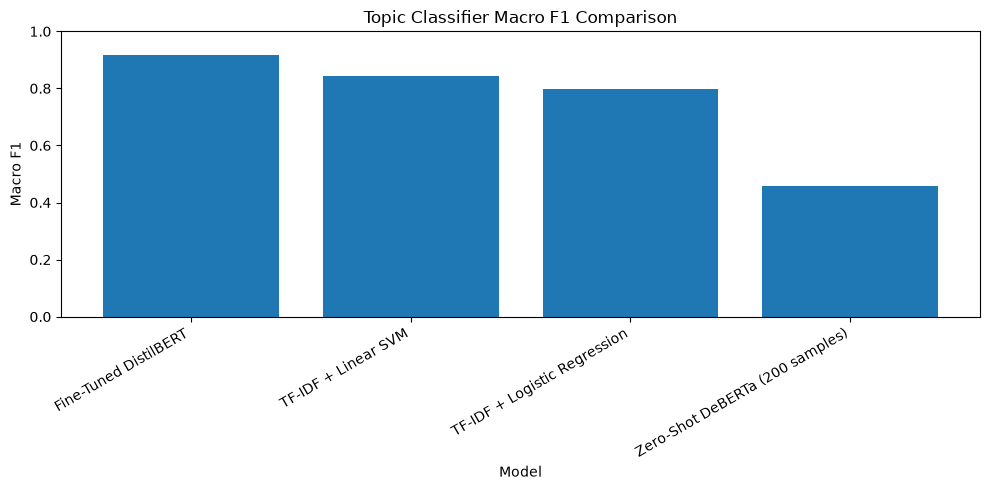

In [89]:
plt.figure(figsize=(10, 5))

plt.bar(topic_model_comparison_df["model"],topic_model_comparison_df["macro_f1"])

plt.title("Topic Classifier Macro F1 Comparison")

plt.xlabel("Model")
plt.ylabel("Macro F1")

plt.xticks(rotation=30,ha="right")

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

Visualize accuracy comparison

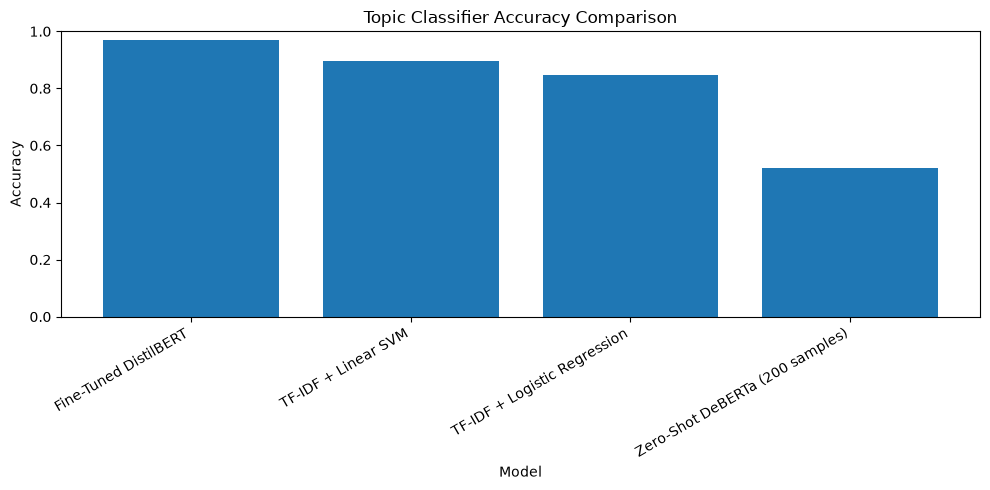

In [90]:
plt.figure(figsize=(10, 5))

plt.bar(topic_model_comparison_df["model"],topic_model_comparison_df["accuracy"])

plt.title("Topic Classifier Accuracy Comparison")

plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=30,ha="right")

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

Visualize training time

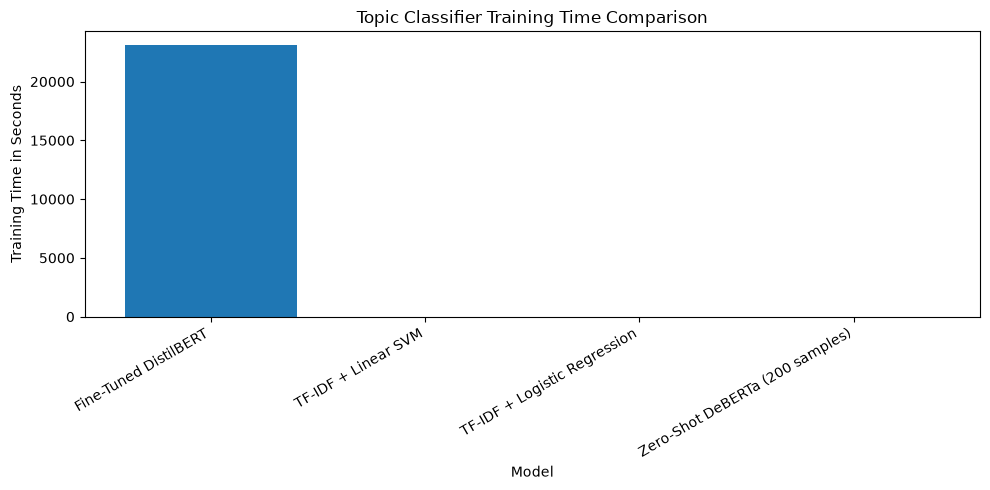

In [91]:
plt.figure(figsize=(10, 5))

plt.bar(topic_model_comparison_df["model"],topic_model_comparison_df["training_time_seconds"])

plt.title("Topic Classifier Training Time Comparison")

plt.xlabel("Model")
plt.ylabel("Training Time in Seconds")

plt.xticks(rotation=30,ha="right")

plt.tight_layout()
plt.show()

Save the comparison table

In [92]:
MODEL_COMPARISON_PATH = (OUTPUT_DIR/ "topic_model_comparison.csv")

topic_model_comparison_df.to_csv(MODEL_COMPARISON_PATH,index=False)

print("Model comparison saved to:",MODEL_COMPARISON_PATH)

Model comparison saved to: D:\FullStack_Academic\Final Capstone\EmoExpress\outputs\topic_classifier\topic_model_comparison.csv


Save the classical models

In [94]:
LOGISTIC_MODEL_PATH = (MODEL_DIR/ "tfidf_logistic_topic_classifier.joblib")

SVM_MODEL_PATH = (MODEL_DIR/ "tfidf_linear_svm_topic_classifier.joblib")

LABEL_ENCODER_PATH = (MODEL_DIR/ "topic_label_encoder.joblib")

joblib.dump(logistic_regression_pipeline,LOGISTIC_MODEL_PATH)

joblib.dump(linear_svm_pipeline, SVM_MODEL_PATH)

joblib.dump(label_encoder,LABEL_ENCODER_PATH)

print("Logistic Regression saved to:",LOGISTIC_MODEL_PATH)

print("Linear SVM saved to:",SVM_MODEL_PATH)

print("Label encoder saved to:",LABEL_ENCODER_PATH)

Logistic Regression saved to: D:\FullStack_Academic\Final Capstone\EmoExpress\models\topic_classifier\tfidf_logistic_topic_classifier.joblib
Linear SVM saved to: D:\FullStack_Academic\Final Capstone\EmoExpress\models\topic_classifier\tfidf_linear_svm_topic_classifier.joblib
Label encoder saved to: D:\FullStack_Academic\Final Capstone\EmoExpress\models\topic_classifier\topic_label_encoder.joblib


Save DistilBERT

In [95]:
FINAL_DISTILBERT_DIR = (MODEL_DIR / "distilbert_topic_classifier")

topic_trainer.save_model(str(FINAL_DISTILBERT_DIR))

topic_tokenizer.save_pretrained(str(FINAL_DISTILBERT_DIR))

print("DistilBERT topic classifier saved to:",FINAL_DISTILBERT_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT topic classifier saved to: D:\FullStack_Academic\Final Capstone\EmoExpress\models\topic_classifier\distilbert_topic_classifier


## Identify the best model


In [96]:
best_model_row = (topic_model_comparison_df.iloc[0])

BEST_MODEL_NAME = (best_model_row["model"])

BEST_MACRO_F1 = float(best_model_row["macro_f1"])

BEST_ACCURACY = float(best_model_row["accuracy"])

print("Best model:",BEST_MODEL_NAME)

print("Best Macro F1:",f"{BEST_MACRO_F1:.4f}")

print("Best accuracy:",f"{BEST_ACCURACY:.4f}")

Best model: Fine-Tuned DistilBERT
Best Macro F1: 0.9153
Best accuracy: 0.9686


## Conclusion

In this notebook, I built the topic classification component of EmoExpress using the EmpatheticDialogues dataset.

I first explored and preprocessed the conversations by grouping the utterances and cleaning the text. Because the dataset does not provide the topic labels needed for EmoExpress, I defined the topic categories and used keyword-based weak supervision to generate the initial labels. I then reviewed the topic distribution, handled ambiguous examples, and prepared the train, validation, and test datasets.

Next, I trained and evaluated Logistic Regression, Linear SVM, and fine-tuned DistilBERT for single-label topic classification. I mainly used Macro F1 for model comparison because it gives equal importance to each topic class. I also tested zero-shot DeBERTa as a pretrained benchmark without additional training. Because zero-shot evaluation was very slow on my CPU, I evaluated it on a smaller sample instead of the full test set.

From this experiment, I learned how to create topic labels when labeled data is not available and compare traditional ML, fine-tuned, and zero-shot transformer approaches. The selected topic classifier, which is fine-tuned DistilBERT, can now identify the main topic of a user's story and use it to improve RAG retrieval and response generation in the EmoExpress pipeline.
